In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

In [2]:
my_df = pd.read_excel("oficial.xlsx", sheet_name="Codificada")

In [3]:
x = my_df.drop(
    ["Paciente_ID", "Risco de Ataque Cardíaco"],
    axis=1
)

y = my_df["Risco de Ataque Cardíaco"]

In [4]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [5]:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [6]:
print(y_train.value_counts())

Risco de Ataque Cardíaco
0    1195
1     661
Name: count, dtype: int64


In [7]:
smote = SMOTE(random_state=42)

x_train_bal, y_train_bal = smote.fit_resample(
    x_train,
    y_train
)

In [8]:
print(y_train_bal.value_counts())

Risco de Ataque Cardíaco
0    1195
1    1195
Name: count, dtype: int64


In [9]:
print(x_train.shape)

print(x_train_bal.shape)

(1856, 21)
(2390, 21)



RESULTADOS - NAIVE BAYES

Accuracy: 0.5402

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       257
           1       0.35      0.35      0.35       141

    accuracy                           0.54       398
   macro avg       0.50      0.50      0.50       398
weighted avg       0.54      0.54      0.54       398


Matriz de Confusão:
[[165  92]
 [ 91  50]]


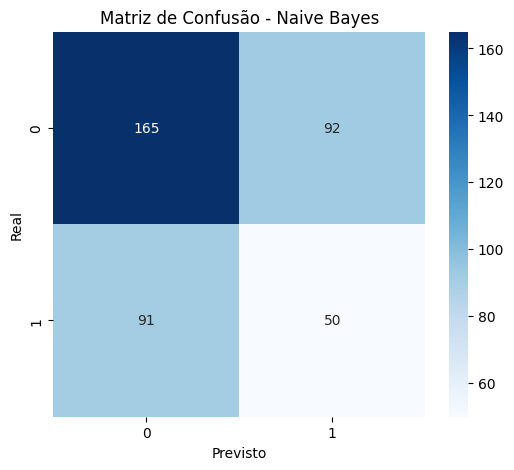


A paciente possui ALTO risco de ataque cardíaco.


c:\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [10]:
# =========================================================
# NAIVE BAYES
# =========================================================

# =========================================================
# NORMALIZAÇÃO DOS DADOS
# =========================================================
# GaussianNB funciona melhor com dados normalizados

scaler = StandardScaler()

x_train_bal = scaler.fit_transform(x_train_bal)

x_test = scaler.transform(x_test)

# =========================================================
# CRIAÇÃO DO MODELO
# =========================================================

model = GaussianNB()

# =========================================================
# TREINAMENTO
# =========================================================

model.fit(x_train_bal, y_train_bal)

# =========================================================
# PREDIÇÕES
# =========================================================

y_pred = model.predict(x_test)

# =========================================================
# AVALIAÇÃO DO MODELO
# =========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("RESULTADOS - NAIVE BAYES")
print("===================================")

print(f"\nAccuracy: {accuracy:.4f}")

# =========================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# =========================================================

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

# =========================================================
# MATRIZ DE CONFUSÃO
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de Confusão:")
print(cm)

# =========================================================
# VISUALIZAÇÃO DA MATRIZ
# =========================================================

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,
    fmt='d',
    cmap='Blues'

)

plt.title('Matriz de Confusão - Naive Bayes')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

# =========================================================
# EXEMPLO DE NOVA PREVISÃO
# =========================================================
# IMPORTANTE:
# A ordem deve seguir EXATAMENTE
# a ordem das colunas da base

nova_paciente = [[

    45,     # Idade
    220,    # Colesterol
    135,    # Pressão Sistólica
    90,     # Pressão Diastólica
    82,     # Batimentos Cardíacos
    1,      # Diabetes
    0,      # Histórico Familiar
    1,      # Fumante
    0,      # Obesidade
    1,      # Consumo de Álcool
    4.0,    # Horas de Exercício Semanal
    2,      # Dieta
    1,      # Problemas Cardíacos Anteriores
    0,      # Uso de Medicamentos
    7,      # Nível de Estresse
    5.0,    # Horas Sedentárias por Dia
    150000, # Renda
    31.2,   # IMC
    280,    # Triglicerídios
    3,      # Dias de Atividade Física por Semana
    6.5     # Horas de Sono por Dia

]]

# =========================================================
# NORMALIZAR NOVO DADO
# =========================================================

nova_paciente = scaler.transform(nova_paciente)

# =========================================================
# PREVISÃO
# =========================================================

previsao = model.predict(nova_paciente)

# =========================================================
# RESULTADO FINAL
# =========================================================

if previsao[0] == 1:

    print("\nA paciente possui ALTO risco de ataque cardíaco.")

else:

    print("\nA paciente possui BAIXO risco de ataque cardíaco.")